# Analisis Aspect-Based Sentiment (ABSA) Ulasan Hotel Multinegara

tujuan untuk melakukan analisis sentimen per-aspek (mis. lokasi, kebersihan, pelayanan) pada ulasan hotel dari berbagai negara.  
Langkah utamanya meliputi: pengumpulan data, pembersihan teks, ekstraksi aspek berbasis keyword, pelabelan sentimen dengan VADER, serta modeling menggunakan TF-IDF dan Logistic Regression.  
Hasilnya akan menunjukkan distribusi sentimen per-aspek di tiap negara untuk membantu memahami kekuatan dan kelemahan layanan hotel.  

# Import semua library yang dibutuhkan untuk analisis data, NLP, dan visualisasi

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import spacy
import subprocess
import sys
import re
import nltk
import tqdm
import matplotlib.pyplot as plt
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm

nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to C:\Users\Hammam
[nltk_data]     Karim\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Fungsi untuk membaca semua file ulasan hotel dari direktori dan menyimpannya ke DataFrame
fungsi load_reviews_from_folder digunakan untuk membaca semua file review dari struktur folder yang terorganisir berdasarkan negara dan hotel. Ia menelusuri setiap folder negara, membaca isi file .txt dari masing-masing hotel, lalu menyusun data tersebut menjadi sebuah DataFrame dengan kolom country, hotel, dan review

In [11]:
def load_reviews_from_folder(folder_path):
    data = []
    for country_folder in os.listdir(folder_path):
        country_path = os.path.join(folder_path, country_folder)
        if os.path.isdir(country_path):
            for file_name in os.listdir(country_path):
                file_path = os.path.join(country_path, file_name)
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        content = f.read()
                except UnicodeDecodeError:
                    with open(file_path, 'r', encoding='ISO-8859-1') as f:
                        content = f.read()
                data.append({
                    'country': country_folder,
                    'hotel': file_name.replace('.txt', ''),
                    'review': content
                })
    return pd.DataFrame(data)


# Menggunakan VADER untuk menganalisis sentimen dari setiap review secara keseluruhan
 menambahkan kolom sentiment ke DataFrame df dengan menentukan apakah setiap review bernada positif, negatif, atau netral. Penilaian dilakukan dengan menghitung skor sentimen menggunakan SentimentIntensityAnalyzer dari VADER, dan tqdm.pandas() digunakan agar proses bisa dipantau dengan progress bar.

In [12]:
tqdm.pandas() 

def get_sentiment_label(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'
    
# 1. Load data
df = load_reviews_from_folder('hotels')
# 2. Proses sentimen (asumsikan fungsi get_sentiment_label sudah ada)
df['sentiment'] = df['review'].progress_apply(get_sentiment_label)

100%|██████████| 2568/2568 [42:32<00:00,  1.01it/s]  


# Memuat Model spaCy dan Pembersihan Teks
memuat model bahasa Inggris kecil dari spaCy (en_core_web_sm) dan otomatis mengunduhnya jika belum tersedia. Fungsi clean_text lalu membersihkan teks dengan mengubah huruf ke kecil, menghapus karakter non-huruf, dan melakukan lemmatization sambil membuang stopword. Selanjutnya, setiap review dibersihkan menggunakan fungsi tersebut dan hasilnya disimpan ke kolom baru clean_review

In [13]:
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)

tqdm.pandas(desc="Cleaning reviews")

df['clean_review'] = df['review'].progress_apply(clean_text)

Cleaning reviews: 100%|██████████| 2568/2568 [1:19:28<00:00,  1.86s/it]  


#  Membuat label aspek berdasarkan keyword sederhana 
 mendefinisikan kategori aspek seperti kamar, layanan, lokasi, dan makanan, masing-masing dengan daftar kata kunci terkait. Fungsi extract_aspects kemudian memeriksa teks review yang sudah dibersihkan, mencari apakah ada kata kunci dari setiap kategori yang muncul, dan mengumpulkan kategori aspek yang relevan ke dalam sebuah daftar. Hasilnya disimpan di kolom baru aspects pada dataframe, sehingga setiap review memiliki daftar aspek yang dibahas.

In [14]:
aspects = {
    'room': ['room', 'suite', 'bed', 'bathroom'],
    'service': ['staff', 'service', 'reception', 'wait'],
    'location': ['location', 'area', 'nearby'],
    'food': ['breakfast', 'food', 'meal', 'restaurant']
}

def extract_aspects(text):
    aspect_list = []
    for aspect, keywords in aspects.items():
        if any(kw in text for kw in keywords):
            aspect_list.append(aspect)
    return aspect_list

df['aspects'] = df['clean_review'].apply(extract_aspects)

In [ ]:
import matplotlib.pyplot as plt

# Hitung frekuensi kemunculan setiap aspek
aspect_counts = df['aspects'].explode().value_counts()

# Plot
aspect_counts.plot(kind='bar', color='skyblue')
plt.title('Frekuensi Kemunculan Aspek dalam Ulasan')
plt.xlabel('Aspek')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()


# Mengubah dataset ke format panjang (long format), 1 baris = 1 aspek per review
mengubah setiap baris di dataframe yang memiliki daftar aspek menjadi beberapa baris terpisah, satu baris per aspek. Baris yang tidak memiliki aspek dihapus agar data lebih bersih. Hasilnya adalah dataframe baru (df_absa) di mana setiap baris merepresentasikan satu aspek dari review.

In [15]:
def explode_aspects(df):
    df_exploded = df.explode('aspects')
    df_exploded = df_exploded.dropna(subset=['aspects'])
    return df_exploded

df_absa = explode_aspects(df)

# Vectorisasi teks dan pelatihan model baseline (Logistic Regression)
proses pelatihan model klasifikasi sentimen. Pertama, data review dan label sentimen dipisah menjadi data latih dan uji dengan pembagian 80:20 secara stratifikasi. Kemudian teks diubah menjadi representasi numerik menggunakan TF-IDF. Model regresi logistik dilatih menggunakan data latih yang sudah diproses. Setelah itu, model digunakan untuk memprediksi sentimen pada data uji. Hasil prediksi kemudian divisualisasikan dalam bentuk confusion matrix dan heatmap laporan klasifikasi untuk mengevaluasi performa model pada tiap kelas sentimen.

<Figure size 600x600 with 0 Axes>

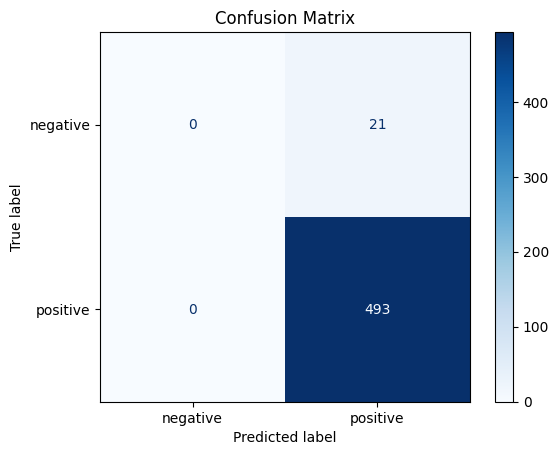

c:\Users\Hammam Karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hammam Karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Hammam Karim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

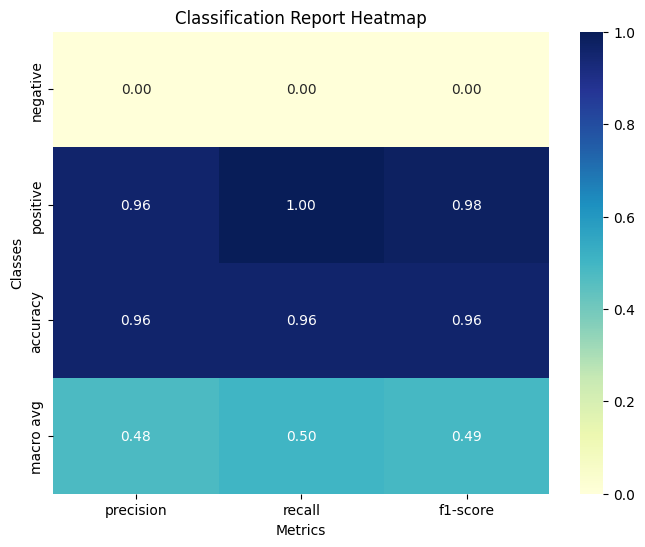

In [16]:
# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

# 2. Vectorize
vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

# 3. Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# 4. Predict
y_pred = model.predict(X_test_vec)

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# 6. Plot Classification Report Heatmap
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8, 6))
sns.heatmap(report_df.iloc[:-1, :-1], annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.xlabel("Metrics")
plt.ylabel("Classes")
plt.show()

# Visualisasi distribusi sentimen per negara
 membuat grafik batang yang menunjukkan jumlah masing-masing kategori sentimen dalam data, dipisahkan berdasarkan negara. Visualisasi ini membantu melihat perbandingan distribusi sentimen di setiap negara secara jelas.

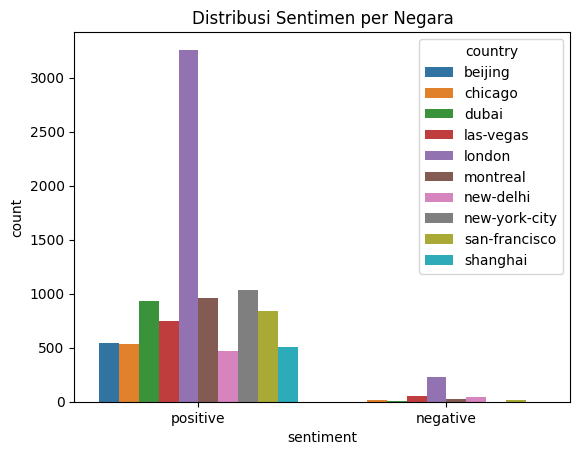

In [17]:
sns.countplot(data=df_absa, x='sentiment', hue='country')
plt.title('Distribusi Sentimen per Negara')
plt.show()